In [1]:
# Header for the notebook
from datetime import datetime
from IPython.display import display, Markdown

# Get the current date
title = "Movement Analysis Project (2025-2026)"
current_date = datetime.now().strftime("%d %B %Y, %H:%M:%S")
authors = "ABDEL-HAMID Chahine"

# Insert the date into the notebook
display(Markdown(f"# {title}"))
display(Markdown(f"{current_date}"))
display(Markdown(f"by {authors}"))

# Movement Analysis Project (2025-2026)

12 May 2026, 03:32:40

by ABDEL-HAMID Chahine

# Data extraction and cleaning

This section extracts the variable **Jump Height (Flight Time) [cm]** from each participant folder inside `data/`.  

Only the following files are used:
- `SJ.xlsx`
- `CMJ.xlsx`

The objective is to create one clean summary table containing:
- `SJ_Mean`
- `CMJ_Mean`

This file will then be used for the visual analysis in Python and the statistical analysis in R.


In [2]:
import os
import pandas as pd

#----- Creation of the dataframe -----

# Folder containing one subfolder per participant
data_folder = "data"

# Function used to rebuild the dataframe with the correct headers
def read_clean_df(file_path):
    df = pd.read_excel(file_path, header=None)

    # Find the row containing the true headers ("Name")
    header_row = df[df.apply(lambda row: row.astype(str).str.contains("Name").any(), axis=1)].index[0]

    # Rebuild the dataframe using the detected header row
    df.columns = df.iloc[header_row]
    df = df.iloc[header_row + 1:].reset_index(drop=True)

    return df

# List used to store the final cleaned values
data = []

# Browse all participant folders
for patient in os.listdir(data_folder):
    patient_path = os.path.join(data_folder, patient)

    # Ignore files that are not folders
    if not os.path.isdir(patient_path):
        continue

    # Store one value for each jump condition
    values = {"SJ_Mean": None, "CMJ_Mean": None}

    # Read the two files of interest
    for file in ["SJ.xlsx", "CMJ.xlsx"]:
        file_path = os.path.join(patient_path, file)

        # Skip the file if it does not exist
        if not os.path.exists(file_path):
            continue

        try:
            df = read_clean_df(file_path)

            # Extract the row corresponding to jump height
            row = df[df["Name"] == "Jump Height (Flight Time) [cm]"]
            mean_value = float(row["Mean"].values[0])

            # Store the value in the correct condition
            if file == "SJ.xlsx":
                values["SJ_Mean"] = mean_value
            else:
                values["CMJ_Mean"] = mean_value

        except Exception as e:
            print(f"{patient} - {file}: error -> {e}")

    # Append one final row per participant
    data.append({
        "Patient": patient,
        "SJ_Mean": values["SJ_Mean"],
        "CMJ_Mean": values["CMJ_Mean"]
    })

# Create the final summary dataframe
df_final = pd.DataFrame(data)

# Export the cleaned file for the next steps
output_path = os.path.join(data_folder, "Global_Jump_Height.xlsx")
df_final.to_excel(output_path, index=False)

# Display the final table
df_final

,Patient,SJ_Mean,CMJ_Mean
0,BOU Jul,35.3,39.7
1,DEL Pie,32.8,36.9
2,FRO Sim,35.8,36.5
3,GIB Val,31.9,35.3
4,IYE Dan,33.0,35.8
5,JOK And,37.3,40.8
6,LOU Art,37.7,41.6
7,MAR Hau,29.4,35.3
8,NOW Ade,39.3,46.1
9,PIE Nat,32.5,37.8


# Plotting of the Results for the Visual Analysis

This section provides a first visual overview of the data.

Two figures are generated:
1. a **boxplot** to compare the overall distribution of SJ and CMJ values,
2. a **paired plot** to visualize the individual change from SJ to CMJ.

The red dashed line represents the group mean.


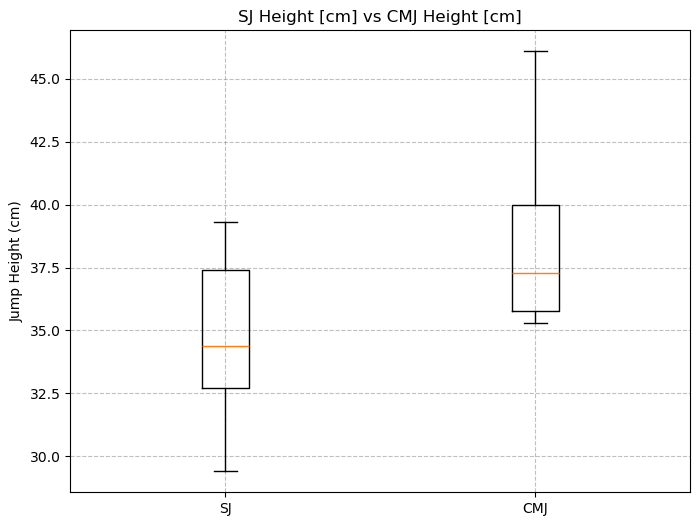

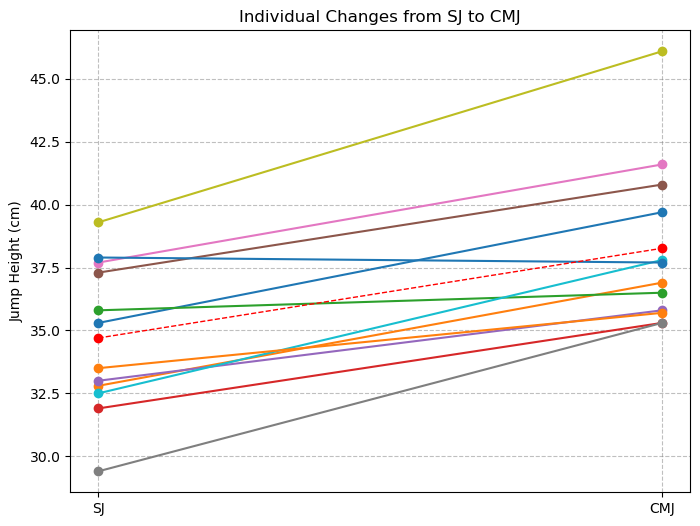

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the cleaned file created in the previous step
df = pd.read_excel("data/Global_Jump_Height.xlsx")

# ----- BOXPLOT -----
plt.figure(figsize=(8, 6))
plt.boxplot([df["SJ_Mean"], df["CMJ_Mean"]], tick_labels=["SJ", "CMJ"])
plt.ylabel("Jump Height (cm)")
plt.title("SJ Height [cm] vs CMJ Height [cm]")
plt.grid(color="grey", linestyle="--", alpha=0.5)
plt.show()

# ----- PAIRED PLOT -----
plt.figure(figsize=(8, 6))

# Plot one line per participant
for i in range(len(df)):
    plt.plot(
        ["SJ", "CMJ"],
        [df.iloc[i]["SJ_Mean"], df.iloc[i]["CMJ_Mean"]],
        marker="o"
    )

# Add the group mean
sj_mean = df["SJ_Mean"].mean()
cmj_mean = df["CMJ_Mean"].mean()
plt.plot(["SJ", "CMJ"], [sj_mean, cmj_mean], color="red", linewidth=1, marker="o", linestyle="--")

plt.ylabel("Jump Height (cm)")
plt.title("Individual Changes from SJ to CMJ")
plt.grid(color="grey", linestyle="--", alpha=0.5)
plt.show()

## Interpretation of the Python output

At this stage, Python provides:

- a **clean paired dataset** (`Global_Jump_Height.xlsx`),
- a **distribution-level comparison** through the boxplot,
- an **individual-level comparison** through the paired plot.

These outputs prepare the data for the final statistical analysis in **R**, where the paired difference between **CMJ** and **SJ** will be formally tested.